### Installing Dependencies

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(accuracy_score, classification_report,confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

### Load Dataset

In [2]:
df = pd.read_csv('intention_dataset.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Basic EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Class Distribution

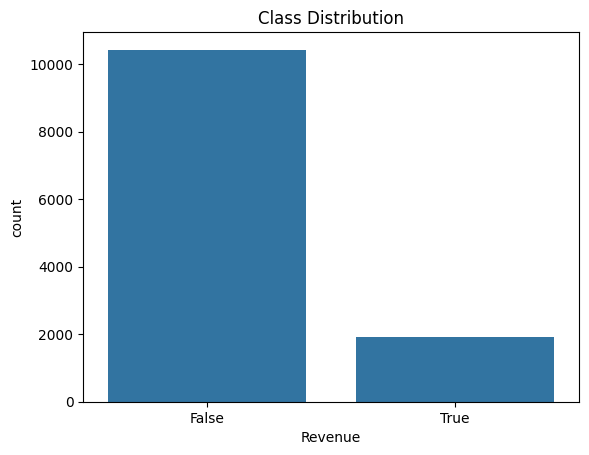

In [6]:
sns.countplot(x='Revenue',data=df)
plt.title('Class Distribution')
plt.show()

In [7]:
df['Revenue'] = df['Revenue'].astype(int)

In [8]:
df = pd.get_dummies(df,drop_first=True)

### Split Data

In [9]:
X = df.drop('Revenue',axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


### Scale Data

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model tuning function

In [12]:
def tune_model(model,param_grid):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]

    print('Model:',model.__class__.__name__)
    print('Best Params:',grid.best_params_)
    print('Accuracy:',accuracy_score(y_test,y_pred))
    print('\nClassification Report:\n',classification_report(y_test,y_pred))
    print('ROC AUC:',roc_auc_score(y_test,y_proba))

    print('='*50)
    return best_model

### Parameter grids

In [13]:
logistic_params = {
    'C':[0.01,0.1,1,10]
}

descision_tree_params = {
    'max_depth':[None, 10,20],
}

random_forest_params = {
    'n_estimators':[100,200],
    'max_depth':[None,10]
}

In [14]:
best_lr = tune_model(LogisticRegression(max_iter=1000),logistic_params)

best_dt = tune_model(DecisionTreeClassifier(),descision_tree_params)

best_rf = tune_model(RandomForestClassifier(),random_forest_params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Model: LogisticRegression
Best Params: {'C': 10}
Accuracy: 0.8815896188158961

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

ROC AUC: 0.8872059370320869
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Model: DecisionTreeClassifier
Best Params: {'max_depth': 10}
Accuracy: 0.8852392538523925

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      2084
           1       0.66      0.54      0.59       382

    accuracy                           0.89      2466
   macro avg       0.79      0.74      0.76      2466
weighted avg       0.88      0.89  

### Select best model

In [15]:
models = {
    'Logistic Regression':best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf
}

best_model = None
best_score = 0

for name,model in models.items():
    score = accuracy_score(y_test,model.predict(X_test))

    if score > best_score:
        best_score = score
        best_model = model
print('Best Model:',best_model)

Best Model: RandomForestClassifier()


### Confusion matrix

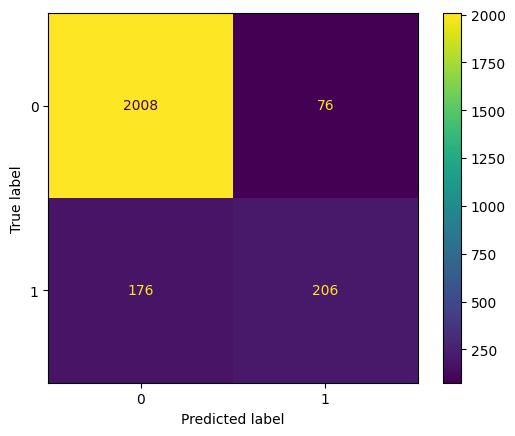

In [16]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### ROC Curve

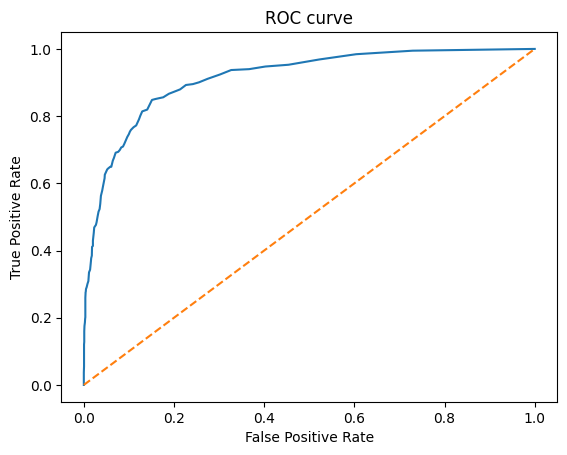

In [17]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC curve')
plt.show()

### Feature importance

In [18]:
feature_imp = best_rf.feature_importances_

imp_df = pd.DataFrame({
    'feature':X.columns,
    'importance':feature_imp
}).sort_values(by='importance',ascending=False)

imp_df.head(10)

,feature,importance
8,PageValues,0.366970
7,ExitRates,0.091259
5,ProductRelated_Duration,0.086747
4,ProductRelated,0.072269
1,Administrative_Duration,0.059572
6,BounceRates,0.055756
0,Administrative,0.042484
12,Region,0.031869
13,TrafficType,0.031516
3,Informational_Duration,0.026609


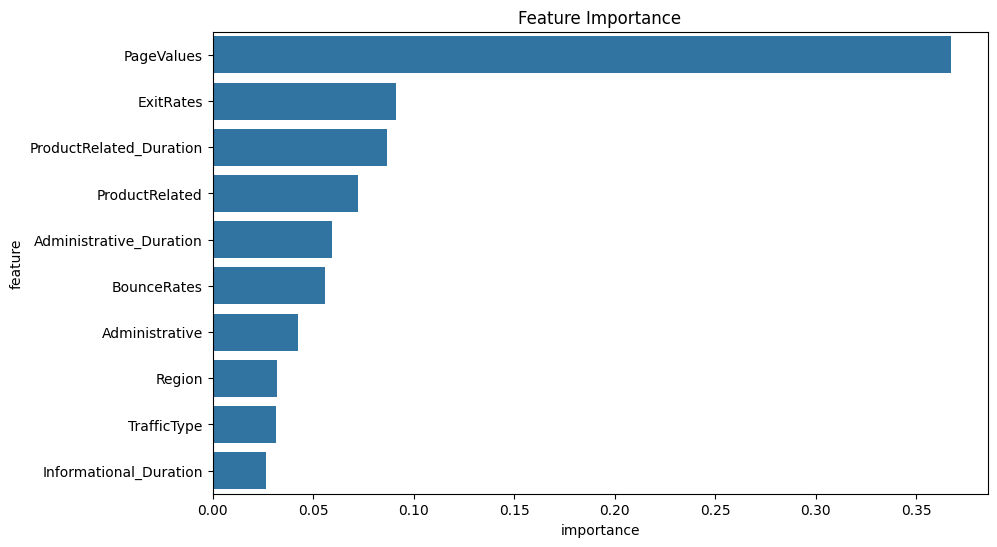

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=imp_df.head(10)
)
plt.title('Feature Importance')
plt.show()

In [20]:
joblib.dump(best_model,'best_model.pkl')

['best_model.pkl']

### Deep Learning (ANN) 

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

In [24]:
dl_model = Sequential()

dl_model.add(Input(shape=(X_train.shape[1],)))

dl_model.add(Dense(64,activation='relu'))
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32,activation='relu'))
dl_model.add(Dropout(0.3))

dl_model.add(Dense(1,activation='sigmoid'))

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
dl_model.fit(
    X_train,y_train,epochs=20,batch_size=32,validation_split=0.2
)

Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8346 - loss: 0.3936 - val_accuracy: 0.8809 - val_loss: 0.2906
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8837 - loss: 0.2922 - val_accuracy: 0.8941 - val_loss: 0.2721
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8887 - loss: 0.2749 - val_accuracy: 0.8966 - val_loss: 0.2636
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8908 - loss: 0.2669 - val_accuracy: 0.8936 - val_loss: 0.2580
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8949 - loss: 0.2590 - val_accuracy: 0.8956 - val_loss: 0.2542
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8968 - loss: 0.2510 - val_accuracy: 0.8956 - val_loss: 0.2538
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8991 - loss: 0.2513 - val_accuracy: 0.8971 - val_loss: 0.2505
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8996 - loss: 0.2459 - val_accuracy: 0.

In [26]:
y_pred_dl = (dl_model.predict(X_test) > 0.5).astype('int32')
print(classification_report(y_test,y_pred_dl))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.70      0.57      0.63       382

    accuracy                           0.89      2466
   macro avg       0.81      0.76      0.78      2466
weighted avg       0.89      0.89      0.89      2466

